# Layer 1 — Supervised Fraud Detection: XGBoost
## Moving from Rule-Based to AI/ML Fraud Detection — Nigerian Fintech

**Purpose:** Train and evaluate an XGBoost classifier on the synthetic Nigerian fintech dataset.  
**Thesis Chapter:** Chapter 5 — Model Development & Evaluation (Layer 1)  

**Baseline to beat (from EDA):**
- Precision : 0.0154
- Recall    : ~0.81
- F1 Score  : 0.0302

Run cells top to bottom. Do not skip sections.

---
## Section 1 — Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
import shap

# Plot styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

SEED = 42
np.random.seed(SEED)

# Baseline scores from rule-based system (Chapter 4)
BASELINE_PRECISION = 0.0154
BASELINE_RECALL    = 0.81
BASELINE_F1        = 0.0302

print('All imports loaded successfully.')

All imports loaded successfully.


---
## Section 2 — Load & Prepare Data

In [2]:
# Load temporal splits produced by synthetic_generator.py
train = pd.read_csv('data/transactions_train.csv', parse_dates=['timestamp'])
val   = pd.read_csv('data/transactions_val.csv',   parse_dates=['timestamp'])
test  = pd.read_csv('data/transactions_test.csv',  parse_dates=['timestamp'])

print(f'Train : {len(train):,} rows | Fraud: {train.is_fraud.sum():,} ({train.is_fraud.mean()*100:.2f}%)')
print(f'Val   : {len(val):,} rows  | Fraud: {val.is_fraud.sum():,} ({val.is_fraud.mean()*100:.2f}%)')
print(f'Test  : {len(test):,} rows  | Fraud: {test.is_fraud.sum():,} ({test.is_fraud.mean()*100:.2f}%)')
print()
print(f'Train date range : {train.timestamp.min().date()} → {train.timestamp.max().date()}')
print(f'Val date range   : {val.timestamp.min().date()} → {val.timestamp.max().date()}')
print(f'Test date range  : {test.timestamp.min().date()} → {test.timestamp.max().date()}')

Train : 140,000 rows | Fraud: 676 (0.48%)
Val   : 30,000 rows  | Fraud: 139 (0.46%)
Test  : 30,000 rows  | Fraud: 171 (0.57%)

Train date range : 2024-01-01 → 2024-09-12
Val date range   : 2024-09-12 → 2024-11-06
Test date range  : 2024-11-06 → 2024-12-30


---
## Section 3 — Feature Engineering

In [3]:
# Categorical columns to encode
CAT_COLS = ['channel', 'sender_bank', 'beneficiary_bank', 'state']

# Features to use for training
# Excludes: identifiers, timestamp, fraud_subtype (leaks label), rule_based_pred
FEATURE_COLS = [
    # Transaction core
    'amount_ngn',
    'is_interbank',
    'is_agent_transaction',
    'is_new_beneficiary',

    # Time features
    'hour_of_day',
    'day_of_week',
    'is_weekend',
    'is_public_holiday',
    'is_off_hours',

    # Nigeria-specific signals
    'sim_age_days',
    'sim_swap_flag',
    'device_fingerprint_changed',
    'geo_displacement_flag',
    'nin_bvn_mismatch',

    # Velocity
    'velocity_1h',
    'velocity_6h',
    'velocity_24h',
    'cumulative_send_24h_ngn',

    # Encoded categoricals (added below)
    'channel_enc',
    'sender_bank_enc',
    'beneficiary_bank_enc',
    'state_enc',
]

TARGET = 'is_fraud'

def encode_and_prepare(df_train, df_val, df_test, cat_cols):
    """Label-encode categoricals. Fit only on train to prevent leakage."""
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df_train[f'{col}_enc'] = le.fit_transform(df_train[col].astype(str))
        df_val[f'{col}_enc']   = le.transform(df_val[col].astype(str))
        df_test[f'{col}_enc']  = le.transform(df_test[col].astype(str))
        encoders[col] = le
    return df_train, df_val, df_test, encoders

train, val, test, encoders = encode_and_prepare(train, val, test, CAT_COLS)

# Convert booleans to int
bool_cols = ['is_interbank','is_agent_transaction','is_new_beneficiary',
             'is_weekend','is_public_holiday','is_off_hours',
             'sim_swap_flag','device_fingerprint_changed',
             'geo_displacement_flag','nin_bvn_mismatch']
for df_ in [train, val, test]:
    for col in bool_cols:
        df_[col] = df_[col].astype(int)

X_train = train[FEATURE_COLS]
y_train = train[TARGET]
X_val   = val[FEATURE_COLS]
y_val   = val[TARGET]
X_test  = test[FEATURE_COLS]
y_test  = test[TARGET]

print(f'Feature matrix shape — Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Features used ({len(FEATURE_COLS)}):')
print(FEATURE_COLS)

Feature matrix shape — Train: (140000, 22) | Val: (30000, 22) | Test: (30000, 22)
Features used (22):
['amount_ngn', 'is_interbank', 'is_agent_transaction', 'is_new_beneficiary', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_public_holiday', 'is_off_hours', 'sim_age_days', 'sim_swap_flag', 'device_fingerprint_changed', 'geo_displacement_flag', 'nin_bvn_mismatch', 'velocity_1h', 'velocity_6h', 'velocity_24h', 'cumulative_send_24h_ngn', 'channel_enc', 'sender_bank_enc', 'beneficiary_bank_enc', 'state_enc']


---
## Section 4 — Handle Class Imbalance
XGBoost's `scale_pos_weight` is a cost-sensitive approach that tells the model
to penalise missing fraud cases more heavily than flagging legitimate ones.

In [4]:
# Calculate class weight ratio
n_legit = (y_train == 0).sum()
n_fraud = (y_train == 1).sum()
scale_pos_weight = n_legit / n_fraud

print(f'Training set — Legitimate: {n_legit:,} | Fraud: {n_fraud:,}')
print(f'scale_pos_weight = {scale_pos_weight:.2f}')
print(f'This tells XGBoost to treat each fraud case as {scale_pos_weight:.0f}x more important.')

Training set — Legitimate: 139,324 | Fraud: 676
scale_pos_weight = 206.10
This tells XGBoost to treat each fraud case as 206x more important.


---
## Section 5 — Train XGBoost Model

In [5]:
model = XGBClassifier(
    # Core parameters
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    subsample         = 0.8,
    colsample_bytree  = 0.8,

    # Imbalance handling
    scale_pos_weight  = scale_pos_weight,

    # Regularisation
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,

    # Reproducibility & performance
    random_state      = SEED,
    eval_metric       = 'aucpr',     # Area under Precision-Recall curve
    early_stopping_rounds = 30,
    tree_method       = 'hist',
    verbosity         = 0,
)

print('Training XGBoost model...')
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f'\nBest iteration : {model.best_iteration}')
print('Training complete.')

Training XGBoost model...
[0]	validation_0-aucpr:0.87444
[50]	validation_0-aucpr:0.96430
[100]	validation_0-aucpr:0.97517
[150]	validation_0-aucpr:0.97828
[200]	validation_0-aucpr:0.97997
[250]	validation_0-aucpr:0.98140
[300]	validation_0-aucpr:0.98202
[336]	validation_0-aucpr:0.98197

Best iteration : 306
Training complete.


---
## Section 6 — Threshold Tuning
Default threshold (0.5) is rarely optimal for imbalanced fraud data.
We find the threshold that maximises F1 on the validation set.

Best threshold (max F1 on val set) : 0.85
At this threshold:
  Precision : 0.9848
  Recall    : 0.9353
  F1        : 0.9594


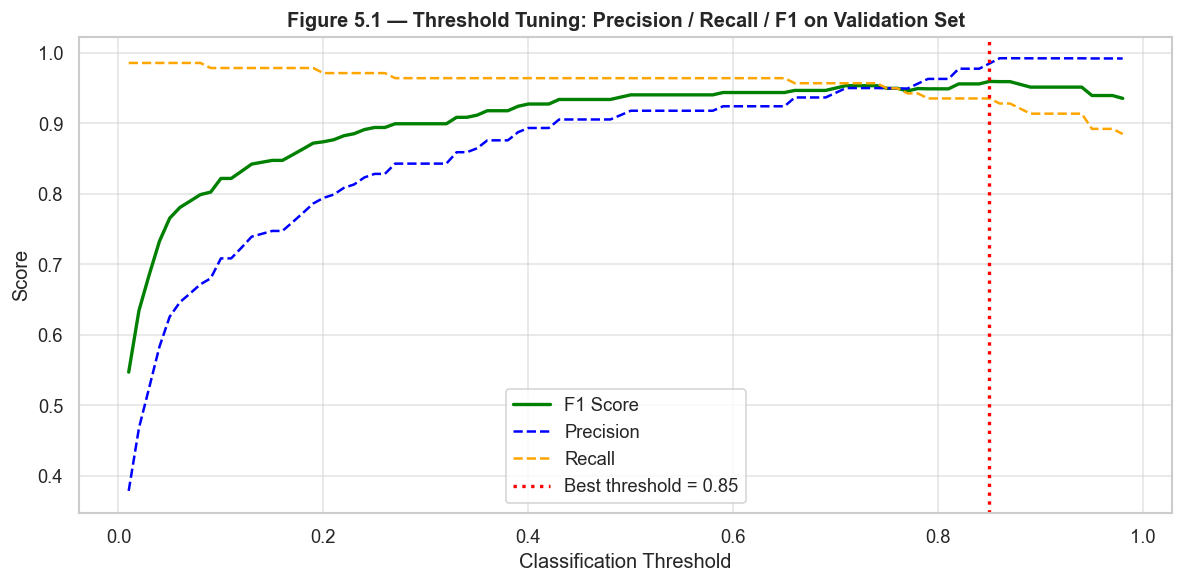

In [6]:
# Get probability scores on validation set
val_probs = model.predict_proba(X_val)[:, 1]

# Sweep thresholds
thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores  = []
precisions = []
recalls    = []

for t in thresholds:
    preds = (val_probs >= t).astype(int)
    f1_scores.append(f1_score(y_val, preds, zero_division=0))
    precisions.append(precision_score(y_val, preds, zero_division=0))
    recalls.append(recall_score(y_val, preds, zero_division=0))

best_idx       = np.argmax(f1_scores)
BEST_THRESHOLD = thresholds[best_idx]

print(f'Best threshold (max F1 on val set) : {BEST_THRESHOLD:.2f}')
print(f'At this threshold:')
print(f'  Precision : {precisions[best_idx]:.4f}')
print(f'  Recall    : {recalls[best_idx]:.4f}')
print(f'  F1        : {f1_scores[best_idx]:.4f}')

# Plot threshold curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores,  label='F1 Score',  color='green',  linewidth=2)
ax.plot(thresholds, precisions, label='Precision',  color='blue',   linewidth=1.5, linestyle='--')
ax.plot(thresholds, recalls,    label='Recall',     color='orange', linewidth=1.5, linestyle='--')
ax.axvline(x=BEST_THRESHOLD, color='red', linestyle=':', linewidth=2,
           label=f'Best threshold = {BEST_THRESHOLD:.2f}')
ax.set_xlabel('Classification Threshold')
ax.set_ylabel('Score')
ax.set_title('Figure 5.1 — Threshold Tuning: Precision / Recall / F1 on Validation Set',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('data/fig5_1_threshold_tuning.png', bbox_inches='tight')
plt.show()

---
## Section 7 — Evaluate on Test Set (Final Results)

In [7]:
# Get test probabilities and apply best threshold
test_probs = model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= BEST_THRESHOLD).astype(int)

# Core metrics
precision = precision_score(y_test, test_preds)
recall    = recall_score(y_test, test_preds)
f1        = f1_score(y_test, test_preds)
roc_auc   = roc_auc_score(y_test, test_probs)
pr_auc    = average_precision_score(y_test, test_probs)

print('='*60)
print('XGBOOST LAYER 1 — TEST SET RESULTS')
print('='*60)
print(f'Threshold used    : {BEST_THRESHOLD:.2f}')
print()
print(f'{"Metric":<20} {"Rule-Based":>12} {"XGBoost":>12} {"Improvement":>12}')
print('-'*60)
print(f'{"Precision":<20} {BASELINE_PRECISION:>12.4f} {precision:>12.4f} {(precision-BASELINE_PRECISION):>+12.4f}')
print(f'{"Recall":<20} {BASELINE_RECALL:>12.4f} {recall:>12.4f} {(recall-BASELINE_RECALL):>+12.4f}')
print(f'{"F1 Score":<20} {BASELINE_F1:>12.4f} {f1:>12.4f} {(f1-BASELINE_F1):>+12.4f}')
print(f'{"ROC-AUC":<20} {"N/A":>12} {roc_auc:>12.4f}')
print(f'{"PR-AUC":<20} {"N/A":>12} {pr_auc:>12.4f}')
print('='*60)
print()
print(classification_report(y_test, test_preds, target_names=['Legitimate', 'Fraud']))

XGBOOST LAYER 1 — TEST SET RESULTS
Threshold used    : 0.85

Metric                 Rule-Based      XGBoost  Improvement
------------------------------------------------------------
Precision                  0.0154       0.9756      +0.9602
Recall                     0.8100       0.9357      +0.1257
F1 Score                   0.0302       0.9552      +0.9250
ROC-AUC                       N/A       0.9995
PR-AUC                        N/A       0.9784

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     29829
       Fraud       0.98      0.94      0.96       171

    accuracy                           1.00     30000
   macro avg       0.99      0.97      0.98     30000
weighted avg       1.00      1.00      1.00     30000



---
## Section 8 — ROC & Precision-Recall Curves (Thesis Figure 5.2)

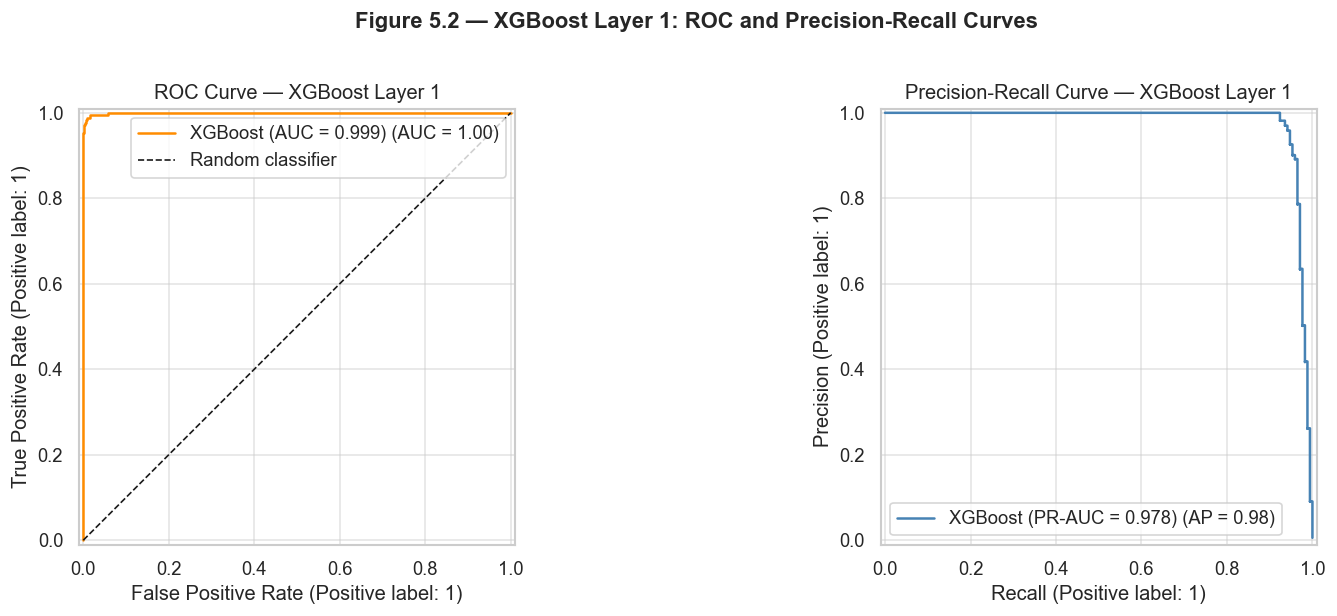

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test, test_probs, ax=axes[0],
    name=f'XGBoost (AUC = {roc_auc:.3f})',
    color='darkorange'
)
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random classifier')
axes[0].set_title('ROC Curve — XGBoost Layer 1')
axes[0].legend()

PrecisionRecallDisplay.from_predictions(
    y_test, test_probs, ax=axes[1],
    name=f'XGBoost (PR-AUC = {pr_auc:.3f})',
    color='steelblue'
)
axes[1].set_title('Precision-Recall Curve — XGBoost Layer 1')
axes[1].legend()

plt.suptitle('Figure 5.2 — XGBoost Layer 1: ROC and Precision-Recall Curves',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig5_2_roc_pr_curves.png', bbox_inches='tight')
plt.show()

---
## Section 9 — Confusion Matrix (Thesis Figure 5.3)

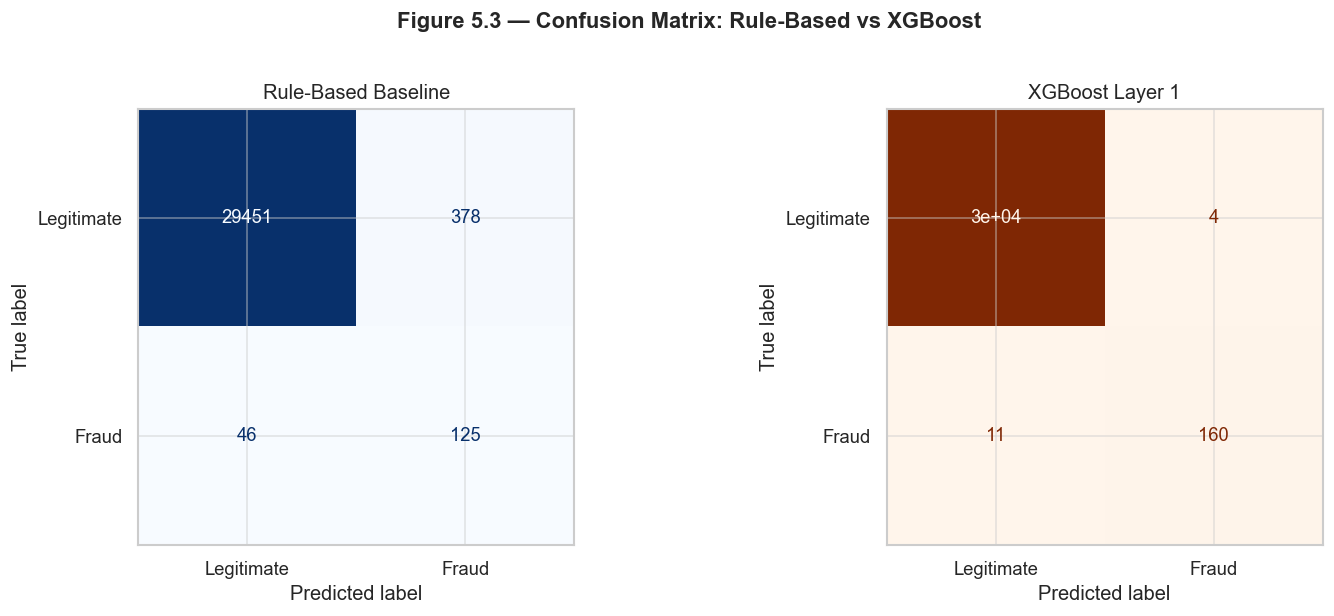

True Positives  (Fraud caught)          : 160
False Negatives (Fraud missed)          : 11
False Positives (Legitimate flagged)    : 4
True Negatives  (Legitimate passed)     : 29825

False Positive Rate : 0.01% of legitimate transactions wrongly blocked


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Rule-based confusion matrix
rule_preds = ((test['amount_ngn'] > 500_000) |
              (test['velocity_1h'] > 5) |
              (test['sim_swap_flag'] == 1) |
              ((test['is_off_hours'] == 1) & (test['amount_ngn'] > 100_000))).astype(int)

cm_rule = confusion_matrix(y_test, rule_preds)
ConfusionMatrixDisplay(cm_rule, display_labels=['Legitimate','Fraud']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Rule-Based Baseline')

# XGBoost confusion matrix
cm_xgb = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(cm_xgb, display_labels=['Legitimate','Fraud']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('XGBoost Layer 1')

plt.suptitle('Figure 5.3 — Confusion Matrix: Rule-Based vs XGBoost',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig5_3_confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm_xgb.ravel()
print(f'True Positives  (Fraud caught)          : {tp}')
print(f'False Negatives (Fraud missed)          : {fn}')
print(f'False Positives (Legitimate flagged)    : {fp}')
print(f'True Negatives  (Legitimate passed)     : {tn}')
print(f'\nFalse Positive Rate : {fp/(fp+tn)*100:.2f}% of legitimate transactions wrongly blocked')

---
## Section 10 — SHAP Explainability (Thesis Figure 5.4)
SHAP values explain WHY the model made each decision.
This is required for NDPA compliance and regulatory transparency.

Computing SHAP values (this takes ~30 seconds)...


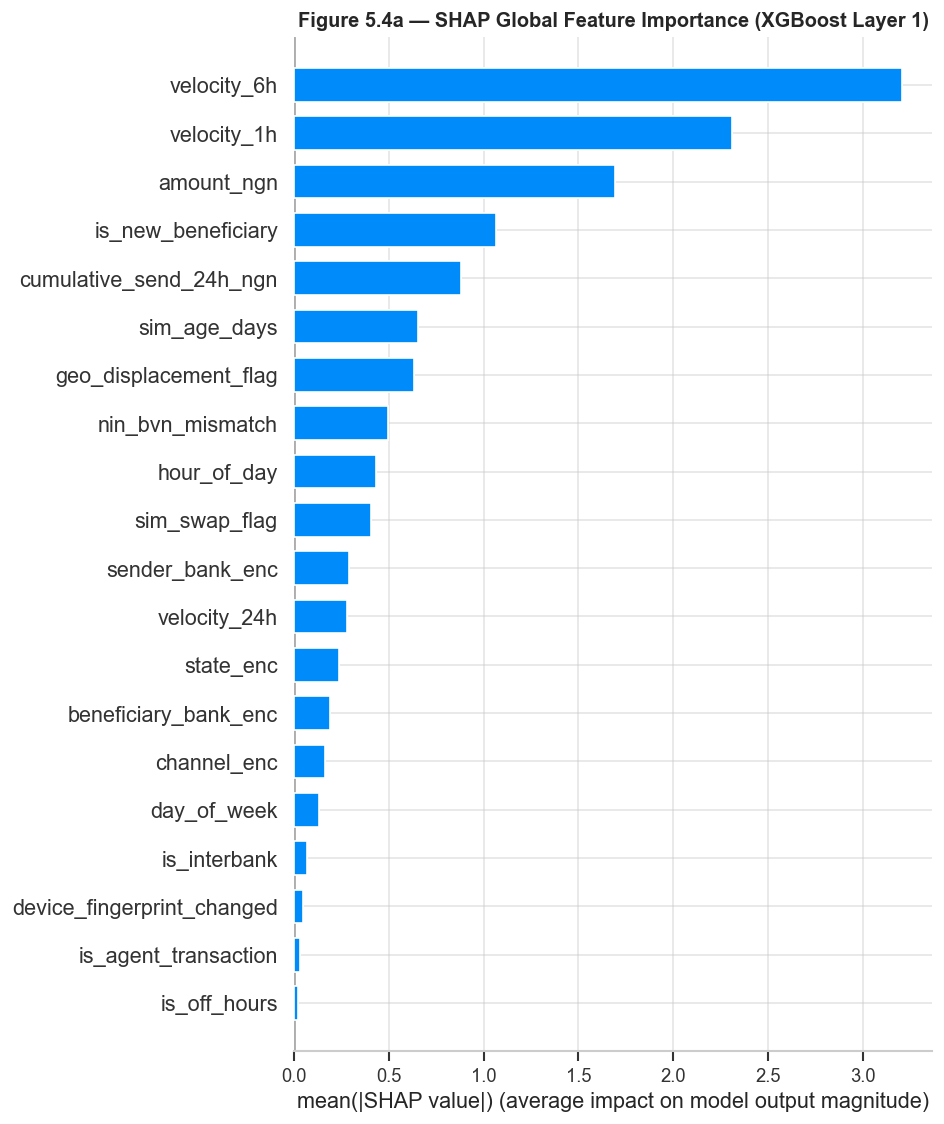

Saved: data/fig5_4a_shap_importance.png


In [10]:
print('Computing SHAP values (this takes ~30 seconds)...')

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global feature importance — summary plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    show=False,
    max_display=20
)
plt.title('Figure 5.4a — SHAP Global Feature Importance (XGBoost Layer 1)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('data/fig5_4a_shap_importance.png', bbox_inches='tight')
plt.show()
print('Saved: data/fig5_4a_shap_importance.png')

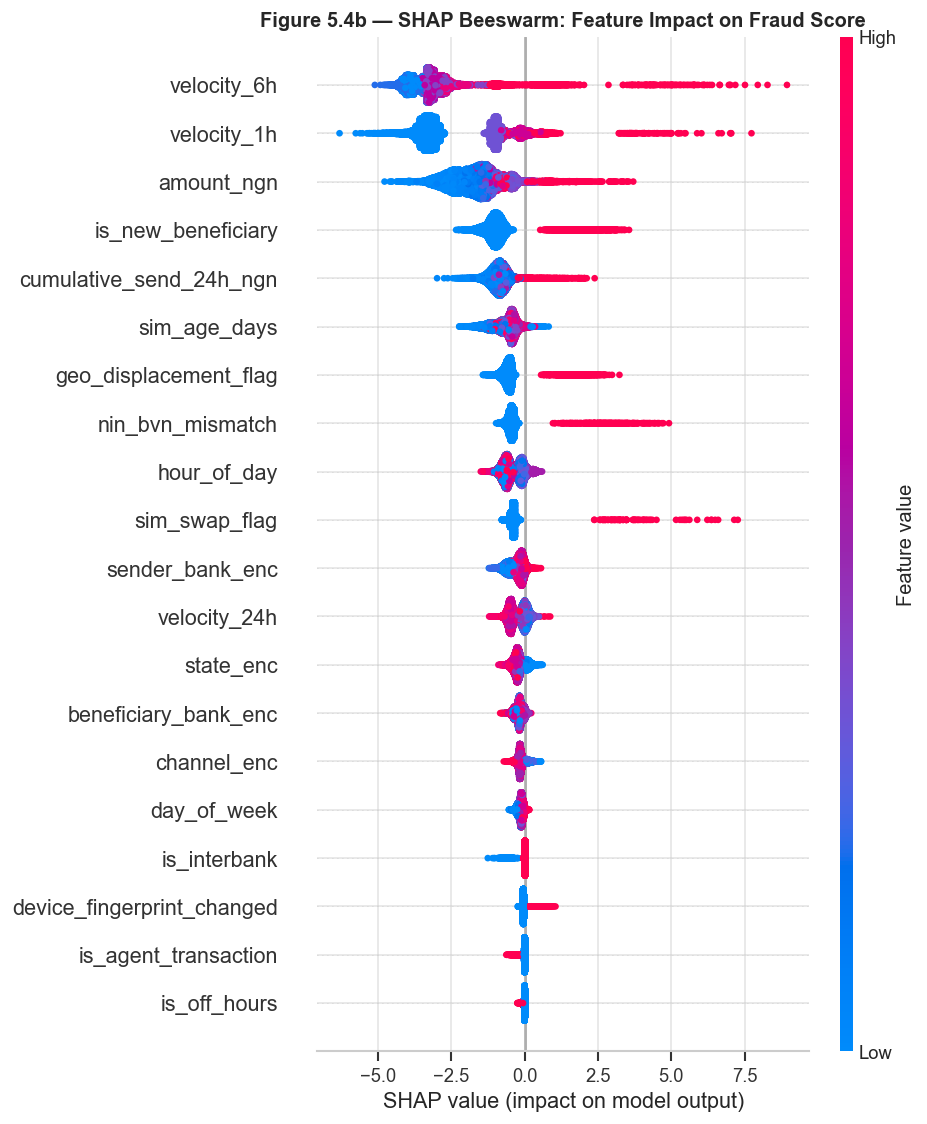

Saved: data/fig5_4b_shap_beeswarm.png


In [11]:
# SHAP beeswarm — shows direction and magnitude of each feature
shap.summary_plot(
    shap_values, X_test,
    show=False,
    max_display=20
)
plt.title('Figure 5.4b — SHAP Beeswarm: Feature Impact on Fraud Score',
          fontweight='bold')
plt.tight_layout()
plt.savefig('data/fig5_4b_shap_beeswarm.png', bbox_inches='tight')
plt.show()
print('Saved: data/fig5_4b_shap_beeswarm.png')

In [12]:
# Individual transaction explanation — NDPA compliance demo
# Show why a specific fraud case was flagged
fraud_indices = np.where(y_test.values == 1)[0]
sample_idx    = fraud_indices[0]   # first fraud case in test set

print(f'Explaining prediction for test transaction index {sample_idx}')
print(f'True label      : {"FRAUD" if y_test.iloc[sample_idx] == 1 else "LEGITIMATE"}')
print(f'Model score     : {test_probs[sample_idx]:.4f}')
print(f'Model decision  : {"FRAUD" if test_preds[sample_idx] == 1 else "LEGITIMATE"} (threshold={BEST_THRESHOLD:.2f})')
print()

# Top contributing features for this transaction
shap_row   = pd.Series(shap_values[sample_idx], index=FEATURE_COLS)
top_shap   = shap_row.abs().sort_values(ascending=False).head(8)
print('Top 8 features driving this decision:')
for feat in top_shap.index:
    direction = '↑ FRAUD' if shap_row[feat] > 0 else '↓ LEGIT'
    print(f'  {feat:<35} SHAP={shap_row[feat]:+.4f}  {direction}  value={X_test.iloc[sample_idx][feat]}')

Explaining prediction for test transaction index 591
True label      : FRAUD
Model score     : 1.0000
Model decision  : FRAUD (threshold=0.85)

Top 8 features driving this decision:
  velocity_6h                         SHAP=+5.7830  ↑ FRAUD  value=18.0
  sim_swap_flag                       SHAP=+4.0732  ↑ FRAUD  value=1.0
  amount_ngn                          SHAP=+0.9173  ↑ FRAUD  value=4773193.21
  cumulative_send_24h_ngn             SHAP=+0.7770  ↑ FRAUD  value=153312918.04
  is_new_beneficiary                  SHAP=-0.6967  ↓ LEGIT  value=0.0
  velocity_1h                         SHAP=+0.5159  ↑ FRAUD  value=3.0
  is_interbank                        SHAP=-0.4584  ↓ LEGIT  value=0.0
  sim_age_days                        SHAP=+0.4260  ↑ FRAUD  value=0.0


---
## Section 11 — Save Model & Results

In [13]:
import os, json
import pickle

os.makedirs('models', exist_ok=True)

# Save model
with open('models/xgboost_layer1.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save results for comparison table in thesis
results = {
    'model'             : 'XGBoost Layer 1',
    'threshold'         : float(BEST_THRESHOLD),
    'precision'         : float(round(precision, 4)),
    'recall'            : float(round(recall, 4)),
    'f1'                : float(round(f1, 4)),
    'roc_auc'           : float(round(roc_auc, 4)),
    'pr_auc'            : float(round(pr_auc, 4)),
    'best_iteration'    : int(model.best_iteration),
    'n_features'        : len(FEATURE_COLS),
    'baseline_f1'       : BASELINE_F1,
    'f1_improvement'    : float(round(f1 - BASELINE_F1, 4)),
}

with open('models/xgboost_layer1_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Model saved     : models/xgboost_layer1.pkl')
print('Results saved   : models/xgboost_layer1_results.json')
print()
print(json.dumps(results, indent=2))

Model saved     : models/xgboost_layer1.pkl
Results saved   : models/xgboost_layer1_results.json

{
  "model": "XGBoost Layer 1",
  "threshold": 0.85,
  "precision": 0.9756,
  "recall": 0.9357,
  "f1": 0.9552,
  "roc_auc": 0.9995,
  "pr_auc": 0.9784,
  "best_iteration": 306,
  "n_features": 22,
  "baseline_f1": 0.0302,
  "f1_improvement": 0.925
}


---
## Section 12 — Layer 1 Summary

In [14]:
print('='*60)
print('LAYER 1 COMPLETE — XGBOOST SUPERVISED MODEL')
print('='*60)
print(f"""
Results vs Rule-Based Baseline
  Precision : {BASELINE_PRECISION:.4f}  →  {precision:.4f}  ({(precision-BASELINE_PRECISION):+.4f})
  Recall    : {BASELINE_RECALL:.4f}  →  {recall:.4f}  ({(recall-BASELINE_RECALL):+.4f})
  F1 Score  : {BASELINE_F1:.4f}  →  {f1:.4f}  ({(f1-BASELINE_F1):+.4f})
  ROC-AUC   : N/A        →  {roc_auc:.4f}
  PR-AUC    : N/A        →  {pr_auc:.4f}

Key Nigeria-specific features identified by SHAP:
  (see fig5_4a_shap_importance.png)

Figures saved:
  fig5_1_threshold_tuning.png
  fig5_2_roc_pr_curves.png
  fig5_3_confusion_matrix.png
  fig5_4a_shap_importance.png
  fig5_4b_shap_beeswarm.png

Next step: model_layer2_anomaly.ipynb
  — Isolation Forest + LSTM Autoencoder
  — Detects unknown/novel fraud patterns
""")

LAYER 1 COMPLETE — XGBOOST SUPERVISED MODEL

Results vs Rule-Based Baseline
  Precision : 0.0154  →  0.9756  (+0.9602)
  Recall    : 0.8100  →  0.9357  (+0.1257)
  F1 Score  : 0.0302  →  0.9552  (+0.9250)
  ROC-AUC   : N/A        →  0.9995
  PR-AUC    : N/A        →  0.9784

Key Nigeria-specific features identified by SHAP:
  (see fig5_4a_shap_importance.png)

Figures saved:
  fig5_1_threshold_tuning.png
  fig5_2_roc_pr_curves.png
  fig5_3_confusion_matrix.png
  fig5_4a_shap_importance.png
  fig5_4b_shap_beeswarm.png

Next step: model_layer2_anomaly.ipynb
  — Isolation Forest + LSTM Autoencoder
  — Detects unknown/novel fraud patterns

